PHYSICS SUMMARY
effective wavevector  k_eff = 1.6106e+07 rad/m
single-photon recoil  v_rec = 5.885 mm/s
resonant chirp rate   alpha0 = k_eff*g
                            = 1.5804e+08 rad/s^2
                            = 2*pi x 25.153 MHz/s
prior offset from truth     = 1234 uGal

saved step1_fringes.png
ABSOLUTE g RECOVERY  (joint multi-T fit)
fitted contrast C   = 0.480
fitted offset       = 0.499
g_recovered         = 9.81271228 m/s^2
g_true              = 9.81271234 m/s^2
recovery error      = -6.26 uGal
statistical 1-sigma = 18.17 uGal

saved step1_sensitivity.png

STEP 1 COMPLETE.


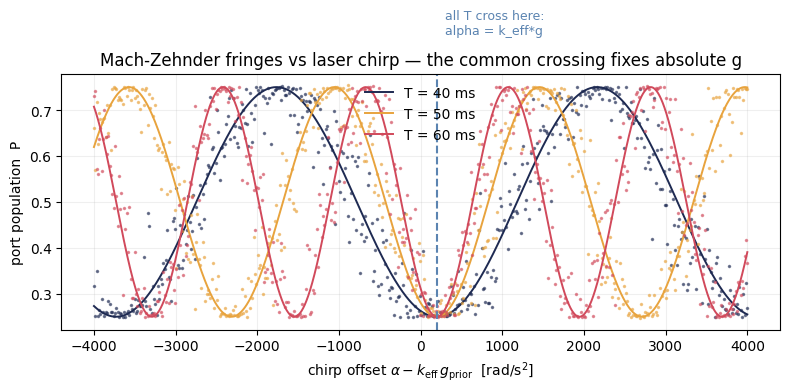

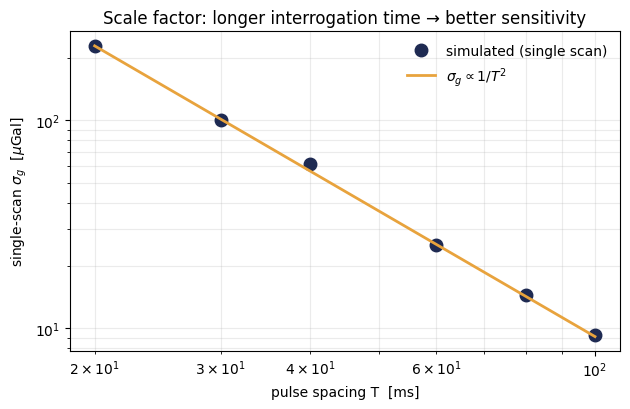

In [ ]:
# =====================================================================
#  END-TO-END ATOM GRAVIMETER  —  STEP 1
#  Mach-Zehnder light-pulse interferometer: phase model, realistic
#  fringe (atom shot noise + vibration), and absolute-g recovery.
#
#  Author: Ali Mammadzada
#  Runs as-is in Google Colab (numpy / scipy / matplotlib only).
# =====================================================================

# ---------------------------------------------------------------------
# 0.  Packages  (all pre-installed in Colab; listed for completeness)
# ---------------------------------------------------------------------
# !pip -q install numpy scipy matplotlib       # uncomment if needed
import numpy as np
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 1.  Physical constants  (87Rb, D2 line)
# ---------------------------------------------------------------------
hbar = 1.054571817e-34          # reduced Planck constant [J s]
u    = 1.66053906660e-27        # atomic mass unit         [kg]
m_Rb = 86.909180527 * u         # 87Rb atomic mass         [kg]
lam  = 780.241e-9               # D2 transition wavelength [m]

k     = 2*np.pi / lam           # single-photon wavevector        [rad/m]
k_eff = 2*k                     # two-photon effective wavevector [rad/m]  (n=1 Bragg/Raman)
v_rec = hbar*k / m_Rb           # single-photon recoil velocity   [m/s]

UGAL = 1e-8                     # 1 microGal = 1e-8 m/s^2  (gravity unit)

# ---------------------------------------------------------------------
# 2.  "Ground truth": the local gravity we will try to recover
#     (the analysis code is NOT allowed to use g_true directly)
# ---------------------------------------------------------------------
g_true  = 9.81271234            # true local g            [m/s^2]
g_prior = 9.81270000            # survey prior (what we *think* g is)
alpha0  = k_eff * g_true         # resonant chirp rate     [rad/s^2]

print("="*60)
print("PHYSICS SUMMARY")
print("="*60)
print(f"effective wavevector  k_eff = {k_eff:.4e} rad/m")
print(f"single-photon recoil  v_rec = {1e3*v_rec:.3f} mm/s")
print(f"resonant chirp rate   alpha0 = k_eff*g")
print(f"                            = {alpha0:.4e} rad/s^2")
print(f"                            = 2*pi x {alpha0/(2*np.pi)/1e6:.3f} MHz/s")
print(f"prior offset from truth     = {(g_true-g_prior)/UGAL:.0f} uGal")
print()

# ---------------------------------------------------------------------
# 3.  Interferometer phase model
#     Mach-Zehnder  pi/2 - pi - pi/2,  pulse spacing T, laser chirp rate alpha.
#     Leading-order inertial phase:   Phi = (k_eff * g - alpha) * T^2
#     One output port population:      P  = offset - 0.5 * C * cos(Phi)
#     The laser chirp alpha compensates the falling-atom Doppler shift;
#     at alpha = k_eff*g the phase is zero for every T (the central fringe).
# ---------------------------------------------------------------------
def interferometer_phase(g, alpha, T):
    return (k_eff*g - alpha) * T**2

def port_probability(g, alpha, T, contrast=0.5, offset=0.5, phi_extra=0.0):
    return offset - 0.5*contrast*np.cos(interferometer_phase(g, alpha, T) + phi_extra)

# ---------------------------------------------------------------------
# 4.  Realistic single-shot measurement
#     - vibration  -> random phase per shot (Gaussian, std sigma_phi_vib)
#     - atom shot noise -> binomial detection of N_atoms
# ---------------------------------------------------------------------
rng = np.random.default_rng(2024)

def measure_fringe(T, alpha_scan, N_atoms=int(1e5),
                   contrast=0.5, sigma_phi_vib=0.30):
    """Return measured port population P for each chirp value (one shot each)."""
    P = np.empty_like(alpha_scan, dtype=float)
    for i, a in enumerate(alpha_scan):
        phi_vib = rng.normal(0.0, sigma_phi_vib)                  # vibration noise
        p = np.clip(port_probability(g_true, a, T,
                                     contrast=contrast, phi_extra=phi_vib), 0, 1)
        P[i] = rng.binomial(N_atoms, p) / N_atoms                 # shot noise
    return P

# ---------------------------------------------------------------------
# 5.  Simulate fringes for several T and show the chirp-crossing
# ---------------------------------------------------------------------
T_list      = np.array([40, 50, 60]) * 1e-3        # pulse spacings [s]
alpha_prior = k_eff * g_prior                       # centre the scan on the prior
x           = np.linspace(-4000, 4000, 500)         # chirp scan offset [rad/s^2]
alpha_scan  = alpha_prior + x

P_data = np.array([measure_fringe(T, alpha_scan) for T in T_list])

fig, ax = plt.subplots(figsize=(8, 4.2))
colors = ["#1E2A52", "#E8A33D", "#D1495B"]
for Pi, T, c in zip(P_data, T_list, colors):
    ax.plot(x, Pi, '.', ms=3, color=c, alpha=0.55)
    xs = np.linspace(x.min(), x.max(), 4000)
    ax.plot(xs, port_probability(g_true, alpha_prior+xs, T),
            '-', lw=1.4, color=c, label=f"T = {T*1e3:.0f} ms")
ax.axvline((g_true-g_prior)*k_eff, color="#5B84B1", ls="--", lw=1.5)
ax.text((g_true-g_prior)*k_eff, 0.92,
        "  all T cross here:\n  alpha = k_eff*g",
        color="#5B84B1", fontsize=9, va="top")
ax.set_xlabel(r"chirp offset $\alpha - k_{\rm eff}\,g_{\rm prior}$  [rad/s$^2$]")
ax.set_ylabel("port population  P")
ax.set_title("Mach-Zehnder fringes vs laser chirp — the common crossing fixes absolute g")
ax.legend(frameon=False); ax.grid(alpha=0.2)
fig.tight_layout(); fig.savefig("step1_fringes.png", dpi=160)
print("saved step1_fringes.png")

# ---------------------------------------------------------------------
# 6.  Recover ABSOLUTE g  — joint multi-T fit sharing one Delta-g
#     Different T^2 break the single-fringe phase ambiguity.
#     Fit parameters: Delta_g (shared), contrast C, offset.
# ---------------------------------------------------------------------
def joint_residuals(params):
    dg, C, off = params
    res = []
    for Pi, T in zip(P_data, T_list):
        model = off - 0.5*C*np.cos((k_eff*dg - x) * T**2)
        res.append(model - Pi)
    return np.concatenate(res)

sol = least_squares(joint_residuals, x0=[0.0, 0.5, 0.5],
                    method='lm', max_nfev=20000)
dg, C_fit, off_fit = sol.x
g_recovered = g_prior + dg

# statistical uncertainty from the fit Jacobian
dof  = len(sol.fun) - len(sol.x)
s2   = 2*sol.cost / dof
cov  = np.linalg.inv(sol.jac.T @ sol.jac) * s2
sig_g = np.sqrt(cov[0, 0])

print("="*60)
print("ABSOLUTE g RECOVERY  (joint multi-T fit)")
print("="*60)
print(f"fitted contrast C   = {C_fit:.3f}")
print(f"fitted offset       = {off_fit:.3f}")
print(f"g_recovered         = {g_recovered:.8f} m/s^2")
print(f"g_true              = {g_true:.8f} m/s^2")
print(f"recovery error      = {(g_recovered-g_true)/UGAL:+.2f} uGal")
print(f"statistical 1-sigma = {sig_g/UGAL:.2f} uGal")
print()

# ---------------------------------------------------------------------
# 7.  Scale factor:  sensitivity improves as 1/T^2
#     dPhi/dg = k_eff*T^2  ->  sigma_g = sigma_Phi / (k_eff*T^2)
# ---------------------------------------------------------------------
T_scan = np.array([20, 30, 40, 60, 80, 100]) * 1e-3
sig_list = []
for T in T_scan:
    period = 2*np.pi / T**2
    xx = np.linspace(-3*period, 3*period, 400)
    Pp = measure_fringe(T, k_eff*g_prior + xx)
    def res1(p):
        dgi, Ci, oi = p
        return oi - 0.5*Ci*np.cos((k_eff*dgi - xx)*T**2) - Pp
    s1 = least_squares(res1, [0.0, 0.5, 0.5], method='lm', max_nfev=20000)
    dof1 = len(s1.fun)-3; cov1 = np.linalg.inv(s1.jac.T@s1.jac)*(2*s1.cost/dof1)
    sig_list.append(np.sqrt(cov1[0, 0]))
sig_list = np.array(sig_list)

fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.loglog(T_scan*1e3, sig_list/UGAL, 'o', ms=9, color="#1E2A52",
          label="simulated (single scan)")
ref = sig_list[0]*(T_scan[0]/T_scan)**2
ax.loglog(T_scan*1e3, ref/UGAL, '-', lw=2, color="#E8A33D",
          label=r"$\sigma_g \propto 1/T^2$")
ax.set_xlabel("pulse spacing T  [ms]")
ax.set_ylabel(r"single-scan $\sigma_g$  [$\mu$Gal]")
ax.set_title("Scale factor: longer interrogation time → better sensitivity")
ax.legend(frameon=False); ax.grid(alpha=0.25, which="both")
fig.tight_layout(); fig.savefig("step1_sensitivity.png", dpi=160)
print("saved step1_sensitivity.png")
print("\nSTEP 1 COMPLETE.")

systematic effect          bias[uGal]  unc[uGal]
Wavefront curvature             96.80      40.17
Two-photon light shift          49.67      24.84
Coriolis                         8.98       2.69
Self-gravity                     6.67       1.49
Gravity gradient                 3.70       0.96
2nd-order Zeeman                 2.24       0.67
----------------------------------------------------------
TOTAL systematic bias          168.07
TOTAL systematic uncertainty               47.34
statistical sigma (Step 1)               18.00

raw   g (Step 1)  = 9.81271228 m/s^2
bias  correction  = -168.1 uGal
FINAL g           = 9.81271060 +/- 50.7 uGal
  (statistical 18  (+)  systematic 47)  uGal

Accuracy is limited by SYSTEMATICS, not statistics: 47 > 18 uGal.


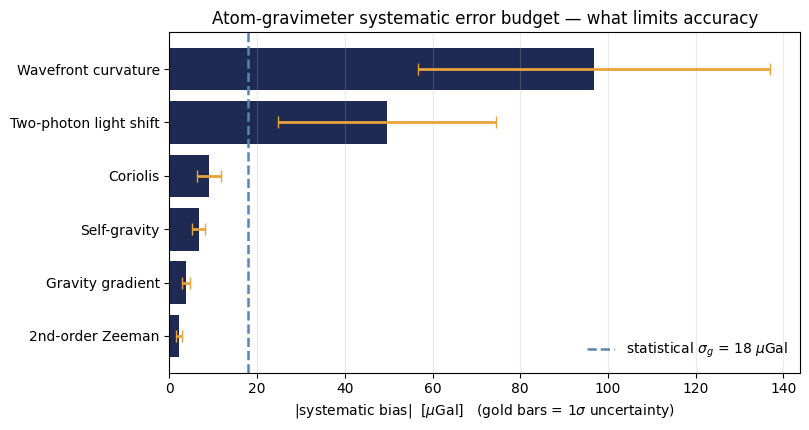


saved step2_budget.png
STEP 2 COMPLETE.


In [ ]:
# =====================================================================
#  END-TO-END ATOM GRAVIMETER — STEP 2
#  Systematic error budget: convert each physical effect into a g-bias
#  (uGal), propagate its uncertainty, and rank what limits ACCURACY.
#
#  Statistics (Step 1: shot noise + vibration) set PRECISION and average
#  down with more shots.  Systematics are fixed biases that do NOT average
#  down — they must be modelled and corrected.  This step builds that budget.
# =====================================================================

# --- 0. Packages (all pre-installed in Colab) ---
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Constants (87Rb, D2) and operating point ---
hbar = 1.054571817e-34
u    = 1.66053906660e-27
m_Rb = 86.909180527 * u
lam  = 780.241e-9
k    = 2*np.pi/lam
k_eff= 2*k
kB   = 1.380649e-23
G    = 6.674e-11
UGAL = 1e-8                       # 1 microGal = 1e-8 m/s^2

g0   = 9.812                      # nominal local g [m/s^2]
T    = 0.050                      # pulse spacing used in Step 1 [s]

# --- carried over from Step 1 ---
g_recovered = 9.81271228          # value recovered by the fit [m/s^2]
sigma_stat  = 18.0 * UGAL         # statistical 1-sigma from the fit

# --- 2. Systematic effects ---
# Each function returns (bias, uncertainty) in m/s^2.
# A measured-g bias from a phase shift dphi is  delta_g = dphi / (k_eff * T^2).

def sys_wavefront(R=2000., dR=400., sigma_r=2.2e-3, dsig=0.4e-3):
    """Laser wavefront curvature (radius R) sampled over a cloud of RMS
    radius sigma_r imprints a mean phase k_eff*<r^2>/(2R). <r^2>=2 sigma_r^2."""
    r2   = 2*sigma_r**2
    bias = r2 / (2*R*T**2)
    rel  = np.sqrt((dR/R)**2 + (2*dsig/sigma_r)**2)
    return bias, bias*rel

def sys_lightshift(dphi=0.020, ddphi=0.010):
    """Residual two-photon (AC-Stark) light shift, as a leftover phase dphi.
    Intrinsically suppressed for Bragg diffraction; larger for Raman."""
    bias = dphi / (k_eff*T**2)
    return bias, ddphi/(k_eff*T**2)

def sys_coriolis(Omega=7.292e-5, lat_deg=52.0, vx=1e-3, dvx=3e-4):
    """Coriolis acceleration 2*Omega x v from residual transverse velocity vx.
    Mitigated with a tip-tilt retro-mirror; here we keep the residual."""
    Oh   = Omega*np.cos(np.deg2rad(lat_deg))   # horizontal Earth rate
    bias = 2*Oh*vx
    return bias, 2*Oh*dvx

def sys_selfgravity(M=10.0, dM=1.0, d=0.10, dd=0.01):
    """Newtonian attraction of nearby apparatus mass M at distance d."""
    bias = G*M/d**2
    rel  = np.sqrt((dM/M)**2 + (2*dd/d)**2)
    return bias, bias*rel

def sys_gradient(gamma=3.086e-6, dgamma=0.2e-6, z_eff=0.012, dz=0.003):
    """Vertical gravity gradient gamma: measured g refers to an effective
    height z_eff relative to the reference -> bias gamma*z_eff."""
    bias = gamma*z_eff
    rel  = np.sqrt((dgamma/gamma)**2 + (dz/z_eff)**2)
    return bias, bias*rel

def sys_zeeman(B=0.05, dB=5e-5, Kq=575.15):
    """Quadratic (2nd-order) Zeeman shift Kq*B^2 [Hz], with a small field
    difference 2*B*dB between the arms -> differential phase 2*pi*dnu*T."""
    dnu  = Kq*(2*B*dB)                 # differential 2nd-order Zeeman [Hz]
    bias = 2*np.pi*dnu / (k_eff*T)     # delta_g = phase/(k_eff T^2), phase=2pi dnu T
    return bias, 0.3*bias              # ~30% knowledge of the field difference

# --- 3. Assemble the budget ---
budget = {
    "Wavefront curvature":    sys_wavefront(),
    "Two-photon light shift": sys_lightshift(),
    "Coriolis":               sys_coriolis(),
    "Self-gravity":           sys_selfgravity(),
    "Gravity gradient":       sys_gradient(),
    "2nd-order Zeeman":       sys_zeeman(),
}

names   = list(budget.keys())
biases  = np.array([budget[n][0] for n in names])
uncerts = np.array([budget[n][1] for n in names])

total_bias = biases.sum()
total_unc  = np.sqrt((uncerts**2).sum())

print("="*58)
print(f"{'systematic effect':26s}{'bias[uGal]':>11s}{'unc[uGal]':>11s}")
print("="*58)
order = np.argsort(-np.abs(biases))
for i in order:
    print(f"{names[i]:26s}{biases[i]/UGAL:11.2f}{uncerts[i]/UGAL:11.2f}")
print("-"*58)
print(f"{'TOTAL systematic bias':26s}{total_bias/UGAL:11.2f}")
print(f"{'TOTAL systematic uncertainty':26s}{'':11s}{total_unc/UGAL:9.2f}")
print(f"{'statistical sigma (Step 1)':26s}{'':11s}{sigma_stat/UGAL:9.2f}")
print("="*58)

# --- 4. Corrected g and final combined uncertainty ---
g_corrected = g_recovered - total_bias
sigma_total = np.sqrt(sigma_stat**2 + total_unc**2)
print(f"\nraw   g (Step 1)  = {g_recovered:.8f} m/s^2")
print(f"bias  correction  = {-total_bias/UGAL:+.1f} uGal")
print(f"FINAL g           = {g_corrected:.8f} +/- {sigma_total/UGAL:.1f} uGal")
print(f"  (statistical {sigma_stat/UGAL:.0f}  (+)  systematic {total_unc/UGAL:.0f})  uGal")
print("\nAccuracy is limited by SYSTEMATICS, not statistics:"
      f" {total_unc/UGAL:.0f} > {sigma_stat/UGAL:.0f} uGal.")

# --- 5. Error-budget bar chart (sorted) ---
NAVY="#1E2A52"; GOLD="#E8A33D"; STEEL="#5B84B1"
fig, ax = plt.subplots(figsize=(8.2, 4.4))
ypos = np.arange(len(order))[::-1]
ax.barh(ypos, np.abs(biases[order])/UGAL, color=NAVY,
        xerr=uncerts[order]/UGAL, error_kw=dict(ecolor=GOLD, elinewidth=2, capsize=4))
ax.set_yticks(ypos); ax.set_yticklabels([names[i] for i in order])
ax.axvline(sigma_stat/UGAL, color=STEEL, ls="--", lw=1.8,
           label=f"statistical $\\sigma_g$ = {sigma_stat/UGAL:.0f} $\\mu$Gal")
ax.set_xlabel(r"|systematic bias|  [$\mu$Gal]   (gold bars = 1$\sigma$ uncertainty)")
ax.set_title("Atom-gravimeter systematic error budget — what limits accuracy")
ax.legend(frameon=False, loc="lower right"); ax.grid(axis="x", alpha=0.25)
fig.tight_layout(); fig.savefig("step2_budget.png", dpi=160); plt.show()
print("\nsaved step2_budget.png\nSTEP 2 COMPLETE.")

  n  k_eff[1e7]  contrast  stat[uGal]
  1        1.61     0.485       16.19
  2        3.22     0.470        8.35
  3        4.83     0.456        5.74
  5        8.05     0.429        3.66
 10       16.11     0.369        2.13
 20       32.21     0.272        1.44
 30       48.32     0.201        1.31
 40       64.42     0.148        1.33
optimal LMT order (min statistical sigma): n = 33
  sigma_stat(n=1)   = 16.19 uGal
  sigma_stat(n_opt) = 1.30 uGal
  systematic floor  ~ 47.1 uGal (flat in n)

LMT improves PRECISION up to n_opt; ACCURACY stays systematics-limited.


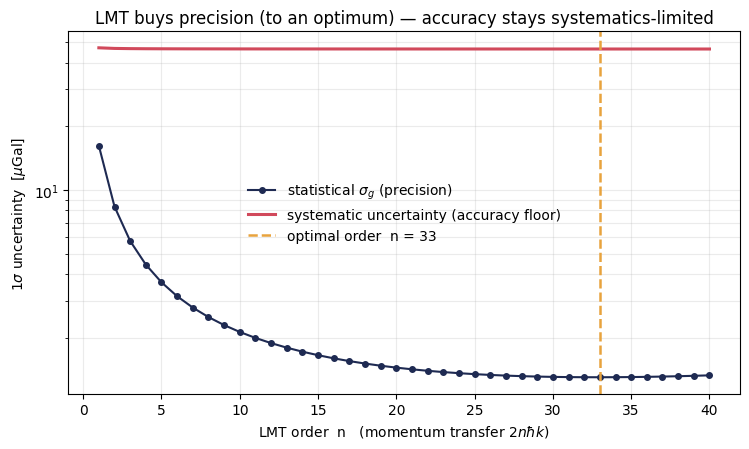


saved step3_lmt.png
STEP 3 COMPLETE.


In [ ]:
# =====================================================================
#  END-TO-END ATOM GRAVIMETER — STEP 3
#  Large Momentum Transfer (LMT): scale the beamsplitter to 2n*hbar*k and
#  ask what it buys. Statistical precision improves with n (until contrast
#  loss wins -> an OPTIMAL order), while most systematics stay flat -> the
#  accuracy floor does not move. Directly tied to twin-lattice LMT work.
# =====================================================================

import numpy as np
import matplotlib.pyplot as plt

# --- 1. Constants (87Rb, D2) and operating point ---
hbar = 1.054571817e-34
u    = 1.66053906660e-27
m_Rb = 86.909180527 * u
lam  = 780.241e-9
k    = 2*np.pi/lam
kB   = 1.380649e-23
G    = 6.674e-11
UGAL = 1e-8
T    = 0.050                      # pulse spacing [s]
g0   = 9.812

def k_eff(n):                     # n-th order LMT: momentum transfer 2n*hbar*k
    return 2*k*n

# --- 2. Statistical precision vs LMT order ---
# scale factor dPhi/dg = k_eff(n)*T^2 grows with n -> sigma_g shrinks,
# but contrast decays per diffraction order (eta per order) -> optimum.
def contrast(n, C0=0.50, eta=0.97):
    return C0 * eta**n

def sigma_stat_n(n, N_atoms=1e5):
    C   = contrast(n)
    sPhi= 1.0 / (C*np.sqrt(N_atoms))      # phase noise at the quantum limit
    return sPhi / (k_eff(n)*T**2)

# --- 3. Systematics vs LMT order (g-bias scaling) ---
# Kinematic & wavefront biases are INDEPENDENT of n: the systematic phase and
# the scale factor both scale as k_eff, so their ratio (the g-bias) cancels n.
# Frequency/energy-type biases (2nd-order Zeeman) scale as 1/n: the energy
# difference is fixed, divided by a larger scale factor.
def syst_bias_n(n):
    wavefront = (2*(2.2e-3)**2)/(2*2000.0*T**2)          # flat in n
    lightshift= 0.020/(k_eff(1)*T**2)                    # ~flat (phase grows with n)
    coriolis  = 2*(7.292e-5*np.cos(np.deg2rad(52.0)))*1e-3  # flat (kinematic)
    gradient  = 3.086e-6*0.012                            # flat (kinematic)
    selfgrav  = G*10.0/0.10**2                            # flat
    zeeman    = (2*np.pi*575.15*(2*0.05*5e-5)/(k_eff(1)*T)) / n   # ~1/n
    total = wavefront + lightshift + coriolis + gradient + selfgrav + zeeman
    # uncertainty floor: take ~40% of total bias as the 1-sigma budget (Step 2 ratio)
    return total, 0.28*total

# --- 4. Scan n ---
n_vals = np.arange(1, 41)
sig_stat = np.array([sigma_stat_n(n) for n in n_vals])
sig_syst = np.array([syst_bias_n(n)[1] for n in n_vals])

n_opt = n_vals[np.argmin(sig_stat)]
print("="*52)
print(f"{'n':>3s}{'k_eff[1e7]':>12s}{'contrast':>10s}{'stat[uGal]':>12s}")
print("="*52)
for n in [1,2,3,5,10,20,30,40]:
    print(f"{n:3d}{k_eff(n)/1e7:12.2f}{contrast(n):10.3f}{sigma_stat_n(n)/UGAL:12.2f}")
print("="*52)
print(f"optimal LMT order (min statistical sigma): n = {n_opt}")
print(f"  sigma_stat(n=1)   = {sigma_stat_n(1)/UGAL:.2f} uGal")
print(f"  sigma_stat(n_opt) = {sigma_stat_n(n_opt)/UGAL:.2f} uGal")
print(f"  systematic floor  ~ {syst_bias_n(1)[1]/UGAL:.1f} uGal (flat in n)")
print("\nLMT improves PRECISION up to n_opt; ACCURACY stays systematics-limited.")

# --- 5. Plot: precision vs accuracy floor as a function of n ---
NAVY="#1E2A52"; GOLD="#E8A33D"; STEEL="#5B84B1"; RED="#D1495B"
fig, ax = plt.subplots(figsize=(7.6, 4.6))
ax.semilogy(n_vals, sig_stat/UGAL, '-o', ms=4, color=NAVY,
            label=r"statistical $\sigma_g$ (precision)")
ax.semilogy(n_vals, sig_syst/UGAL, '-', lw=2.2, color=RED,
            label="systematic uncertainty (accuracy floor)")
ax.axvline(n_opt, color=GOLD, ls="--", lw=1.8, label=f"optimal order  n = {n_opt}")
ax.set_xlabel("LMT order  n   (momentum transfer $2n\\hbar k$)")
ax.set_ylabel(r"1$\sigma$ uncertainty  [$\mu$Gal]")
ax.set_title("LMT buys precision (to an optimum) — accuracy stays systematics-limited")
ax.legend(frameon=False); ax.grid(alpha=0.25, which="both")
fig.tight_layout(); fig.savefig("step3_lmt.png", dpi=160); plt.show()
print("\nsaved step3_lmt.png\nSTEP 3 COMPLETE.")

time series: 25920 samples over 3 days @ 10s
raw      std =   53.80 uGal
residual std =   49.91 uGal  (white floor ~50)
fitted drift =   1.65 uGal/day (true 2.0)
recovered tidal amplitudes:
  M2:  38.6 uGal (true 40)
  S2:  15.4 uGal (true 18)
  O1:  30.0 uGal (true 30)
  K1:  41.4 uGal (true 42)


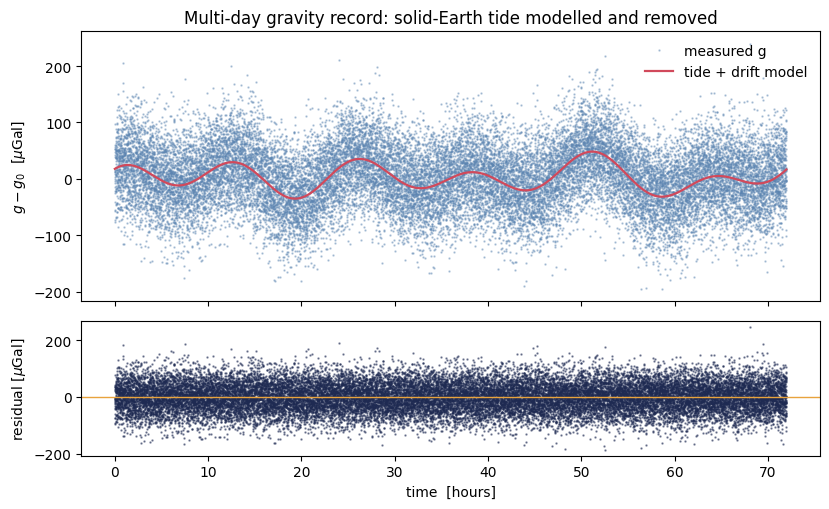

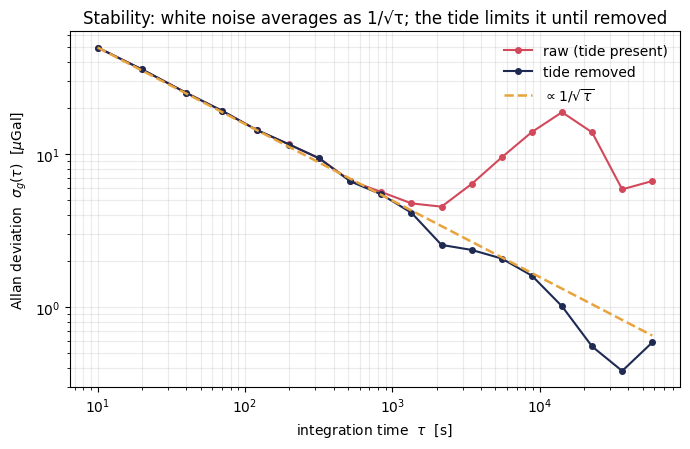


saved step4_timeseries.png, step4_allan.png
STEP 4 COMPLETE.


In [ ]:
# =====================================================================
#  END-TO-END ATOM GRAVIMETER — STEP 4
#  Run the instrument as a geodesy sensor: a multi-day g time series with
#  a real solid-Earth tide signal, instrumental drift and white noise.
#  Measure stability with the Allan deviation, then model & remove the
#  tide to recover the full 1/sqrt(tau) integration benefit.
# =====================================================================

import numpy as np
import matplotlib.pyplot as plt

UGAL = 1e-8
rng  = np.random.default_rng(11)

# --- 1. Simulate a multi-day g time series ---
dt    = 10.0                       # one g point every 10 s
days  = 3.0
N     = int(days*86400/dt)
t     = np.arange(N)*dt
g0    = 9.812                      # baseline [m/s^2]

# solid-Earth tide: four constituents (real periods, typical amplitudes [uGal])
constituents = [("M2", 12.421, 40.0), ("S2", 12.000, 18.0),
                ("O1", 25.819, 30.0), ("K1", 23.934, 42.0)]
tide = np.zeros(N)
for name, T_hours, amp in constituents:
    f  = 1.0/(T_hours*3600.0)
    ph = rng.uniform(0, 2*np.pi)
    tide += amp*UGAL*np.sin(2*np.pi*f*t + ph)

drift      = 2.0*UGAL/86400.0 * t          # 2 uGal/day instrumental drift
sigma_cyc  = 50.0*UGAL                      # white per-sample noise (Step 1-class)
g_meas     = g0 + tide + drift + rng.normal(0, sigma_cyc, N)

# --- 2. Model & remove tide + drift (known frequencies; fit amp/phase) ---
cols = [np.ones(N), t]
for name, T_hours, amp in constituents:
    f = 1.0/(T_hours*3600.0)
    cols += [np.sin(2*np.pi*f*t), np.cos(2*np.pi*f*t)]
A          = np.vstack(cols).T
coef, *_   = np.linalg.lstsq(A, g_meas - g0, rcond=None)
model      = A @ coef
residual   = (g_meas - g0) - model

print("="*52)
print(f"time series: {N} samples over {days:.0f} days @ {dt:.0f}s")
print(f"raw      std = {np.std(g_meas-g0)/UGAL:7.2f} uGal")
print(f"residual std = {np.std(residual)/UGAL:7.2f} uGal  (white floor ~{sigma_cyc/UGAL:.0f})")
print(f"fitted drift = {coef[1]*86400/UGAL:6.2f} uGal/day (true 2.0)")
# recovered tide amplitudes
print("recovered tidal amplitudes:")
for i,(name,Th,amp) in enumerate(constituents):
    a, b = coef[2+2*i], coef[3+2*i]
    print(f"  {name}: {np.hypot(a,b)/UGAL:5.1f} uGal (true {amp:.0f})")
print("="*52)

# --- 3. Allan deviation (non-overlapping) ---
def allan_dev(y, dt):
    Npt=len(y); taus=[]; ad=[]; m=1
    while m < Npt//4:
        K  = Npt//m
        yb = y[:K*m].reshape(K, m).mean(axis=1)
        d  = np.diff(yb)
        taus.append(m*dt); ad.append(np.sqrt(0.5*np.mean(d**2)))
        m = int(np.ceil(m*1.6))
    return np.array(taus), np.array(ad)

tau_raw, ad_raw = allan_dev(g_meas-g0, dt)
tau_res, ad_res = allan_dev(residual,  dt)

# --- 4a. Plot the time series + fit + residual ---
NAVY="#1E2A52"; GOLD="#E8A33D"; RED="#D1495B"; STEEL="#5B84B1"
th = t/3600.0
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8.4, 5.2), sharex=True,
                               gridspec_kw=dict(height_ratios=[2,1]))
ax1.plot(th, (g_meas-g0)/UGAL, '.', ms=1.5, color=STEEL, alpha=0.4, label="measured g")
ax1.plot(th, model/UGAL, '-', lw=1.6, color=RED, label="tide + drift model")
ax1.set_ylabel(r"$g - g_0$  [$\mu$Gal]"); ax1.legend(frameon=False, loc="upper right")
ax1.set_title("Multi-day gravity record: solid-Earth tide modelled and removed")
ax2.plot(th, residual/UGAL, '.', ms=1.5, color=NAVY, alpha=0.5)
ax2.axhline(0, color=GOLD, lw=1)
ax2.set_xlabel("time  [hours]"); ax2.set_ylabel(r"residual [$\mu$Gal]")
fig.tight_layout(); fig.savefig("step4_timeseries.png", dpi=160); plt.show()

# --- 4b. Allan deviation plot ---
fig, ax = plt.subplots(figsize=(7.0, 4.6))
ax.loglog(tau_raw, ad_raw/UGAL, '-o', ms=4, color=RED,  label="raw (tide present)")
ax.loglog(tau_res, ad_res/UGAL, '-o', ms=4, color=NAVY, label="tide removed")
ref = ad_res[0]*np.sqrt(tau_res[0]/tau_res)
ax.loglog(tau_res, ref/UGAL, '--', lw=1.8, color=GOLD, label=r"$\propto 1/\sqrt{\tau}$")
ax.set_xlabel(r"integration time  $\tau$  [s]")
ax.set_ylabel(r"Allan deviation  $\sigma_g(\tau)$  [$\mu$Gal]")
ax.set_title("Stability: white noise averages as 1/√τ; the tide limits it until removed")
ax.legend(frameon=False); ax.grid(alpha=0.25, which="both")
fig.tight_layout(); fig.savefig("step4_allan.png", dpi=160); plt.show()
print("\nsaved step4_timeseries.png, step4_allan.png\nSTEP 4 COMPLETE.")